# Salama Health Modelling Phase 3
### CDI Scores + Child Registry = Immunisation Gap Score (IGS)

**Formula (whitepaper Section 4.2):**

`IGS(c, f, h) = CDI(f, h) x VD(c, h) x A(c)^-1 x UW(c)`

| Component | Description | Source |
|---|---|---|
| CDI(f, h) | Climate Disruption Index for facility f at time h | Phase 2 output |
| VD(c, h) | Vaccination Debt — how overdue child c is | Child registry / DHIS2 |
| A(c) | Accessibility — distance and road quality for child c | GPS coordinates |
| UW(c) | Age-Urgency Weight — younger children score higher | Date of birth |

**Output:** Ranked priority visit list per CHW — who to visit first before the risk window closes

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import json
from datetime import datetime, date

warnings.filterwarnings('ignore')

CDI_PATH  = '/kaggle/input/notebooks/mubarakabanadda/phase2/SSD_CDI_Scores_Phase2.csv'
OUT_DIR   = '/kaggle/working'
TODAY     = pd.Timestamp.today().normalize()

print('Setup complete')
print(f'Reference date: {TODAY.date()}')

Setup complete
Reference date: 2026-06-17


## 1. Load CDI Scores from Phase 2

In [2]:
cdi_df = pd.read_csv(CDI_PATH)

print(f'CDI scores loaded: {len(cdi_df)} facilities')
print(f'Risk distribution:')
print(cdi_df['risk_level'].value_counts())
print(f'\nTop 5 facilities:')
print(cdi_df[['facility_name','state','county','CDI','risk_level']].head(5).to_string(index=False))

CDI scores loaded: 93 facilities
Risk distribution:
risk_level
Medium    59
Low       22
High      12
Name: count, dtype: int64

Top 5 facilities:
 facility_name      state  county   CDI risk_level
NHIAL DIU PHCC      Unity Rubkona 0.501       High
     WAAK PHCC      Unity Rubkona 0.500       High
    MELUF PHCC Upper Nile   Melut 0.477       High
     KAKA PHCC Upper Nile   Manyo 0.458       High
   GIEGER PHCC Upper Nile    Renk 0.450       High


## 2. South Sudan Immunisation Schedule
Standard EPI schedule used in South Sudan per WHO and Ministry of Health.

In [3]:
# EPI schedule: vaccine name -> recommended age in weeks
EPI_SCHEDULE = {
    'BCG':       0,
    'OPV-0':     0,
    'Penta-1':   6,
    'OPV-1':     6,
    'PCV-1':     6,
    'Rota-1':    6,
    'Penta-2':   10,
    'OPV-2':     10,
    'PCV-2':     10,
    'Rota-2':    14,
    'Penta-3':   14,
    'OPV-3':     14,
    'PCV-3':     14,
    'Measles-1': 36,
    'Yellow Fever': 36,
    'Measles-2': 78,
}

# Grace period before a vaccine is considered overdue (weeks)
GRACE_WEEKS = 2

print('EPI Schedule loaded')
print(f'Vaccines tracked: {len(EPI_SCHEDULE)}')
for v, w in EPI_SCHEDULE.items():
    print(f'  {v:15} due at {w:3} weeks ({w//4} months)')

EPI Schedule loaded
Vaccines tracked: 16
  BCG             due at   0 weeks (0 months)
  OPV-0           due at   0 weeks (0 months)
  Penta-1         due at   6 weeks (1 months)
  OPV-1           due at   6 weeks (1 months)
  PCV-1           due at   6 weeks (1 months)
  Rota-1          due at   6 weeks (1 months)
  Penta-2         due at  10 weeks (2 months)
  OPV-2           due at  10 weeks (2 months)
  PCV-2           due at  10 weeks (2 months)
  Rota-2          due at  14 weeks (3 months)
  Penta-3         due at  14 weeks (3 months)
  OPV-3           due at  14 weeks (3 months)
  PCV-3           due at  14 weeks (3 months)
  Measles-1       due at  36 weeks (9 months)
  Yellow Fever    due at  36 weeks (9 months)
  Measles-2       due at  78 weeks (19 months)


## 3. Load or Generate Child Registry
If real DHIS2 or mobile app data is available, load it here.
Otherwise a synthetic registry is generated for demonstration.

In [4]:
CHILD_REGISTRY_PATH = '/kaggle/input/datasets/mubarakabanadda/child-registery/child_registry.csv'

if os.path.exists(CHILD_REGISTRY_PATH):
    print('Loading real child registry...')
    children = pd.read_csv(CHILD_REGISTRY_PATH)
    children['date_of_birth'] = pd.to_datetime(children['date_of_birth'])
    print(f'Children loaded: {len(children):,}')
else:
    print('Real registry not found. Generating synthetic registry for demonstration...')
    print('To use real data: upload child_registry.csv with columns:')
    print('  child_id, facility_name, date_of_birth, sex,')
    print('  caregiver_name, caregiver_phone, location_description,')
    print('  distance_km, last_contact_date')
    print('  and one column per vaccine (BCG, OPV-0, etc.) with date administered or blank')
    print()

    np.random.seed(42)

    # Use top 20 facilities from CDI scores
    top_facilities = cdi_df.head(20)[['facility_name','state','county']].copy()
    n_children     = 500

    # Assign children to facilities
    facility_assignments = np.random.choice(top_facilities.index, size=n_children)

    # Generate dates of birth — children under 2 years old
    max_age_days = 730
    dob_offsets  = np.random.randint(0, max_age_days, size=n_children)
    dob_list     = [TODAY - pd.Timedelta(days=int(d)) for d in dob_offsets]

    children = pd.DataFrame({
        'child_id':            [f'C-{i+1000}' for i in range(n_children)],
        'facility_name':       top_facilities.loc[facility_assignments, 'facility_name'].values,
        'state':               top_facilities.loc[facility_assignments, 'state'].values,
        'county':              top_facilities.loc[facility_assignments, 'county'].values,
        'date_of_birth':       dob_list,
        'sex':                 np.random.choice(['M','F'], size=n_children),
        'caregiver_name':      [f'Caregiver {i}' for i in range(n_children)],
        'caregiver_phone':     [f'+211 9{np.random.randint(10000000,99999999)}' for _ in range(n_children)],
        'location_description':[f'Block {np.random.choice(["A","B","C","D"])} Settlement' for _ in range(n_children)],
        'distance_km':         np.round(np.random.exponential(scale=3.0, size=n_children).clip(0.1, 15), 1),
        'last_contact_date':   [
            (TODAY - pd.Timedelta(days=int(np.random.choice([0,7,14,30,60,90,180,365])))).date()
            if np.random.random() > 0.3 else None
            for _ in range(n_children)
        ],
    })

    # Generate vaccination history
    # Older children have more vaccines; simulate ~60% coverage rates
    for vaccine, due_weeks in EPI_SCHEDULE.items():
        due_days = due_weeks * 7
        vax_dates = []
        for _, row in children.iterrows():
            age_days = (TODAY - row['date_of_birth']).days
            if age_days >= due_days:
                # 60% chance received on time if old enough
                if np.random.random() < 0.60:
                    admin_date = row['date_of_birth'] + pd.Timedelta(days=due_days + np.random.randint(0, 14))
                    vax_dates.append(admin_date.date())
                else:
                    vax_dates.append(None)  # not yet received
            else:
                vax_dates.append(None)  # not yet due
        children[vaccine] = vax_dates

    print(f'Synthetic registry generated: {len(children):,} children')
    print(f'Facilities covered: {children["facility_name"].nunique()}')
    print(f'Age range: 0 to {max_age_days//7} weeks')
    print(f'\nSample record:')
    print(children.iloc[0][['child_id','facility_name','date_of_birth','sex','distance_km']].to_string())

Loading real child registry...
Children loaded: 1,000


## 4. Compute Vaccination Debt VD(c, h)
Vaccination Debt measures how many doses a child is missing relative to what they should have received by now.

In [5]:
def compute_vaccination_debt(child_row, today=TODAY):
    """
    VD(c, h) = number of vaccines overdue for child c at time h
    A vaccine is overdue if:
      - child is old enough to have received it (age > due_age + grace period)
      - child has not received it
    Returns normalised VD between 0 and 1
    """
    dob     = pd.Timestamp(child_row['date_of_birth'])
    age_wks = (today - dob).days / 7

    overdue_count  = 0
    due_count      = 0
    overdue_vaccines = []
    due_vaccines   = []

    for vaccine, due_weeks in EPI_SCHEDULE.items():
        if vaccine not in child_row.index:
            continue
        if age_wks >= (due_weeks + GRACE_WEEKS):
            due_count += 1
            if pd.isna(child_row[vaccine]) or child_row[vaccine] is None:
                overdue_count += 1
                overdue_vaccines.append(vaccine)
        elif age_wks >= due_weeks:
            due_vaccines.append(vaccine)

    vd = overdue_count / max(due_count, 1)
    return vd, overdue_vaccines, due_vaccines


print('Computing vaccination debt for all children...')
vd_list, overdue_list, due_list = [], [], []

for _, row in children.iterrows():
    vd, overdue, due = compute_vaccination_debt(row)
    vd_list.append(vd)
    overdue_list.append(overdue)
    due_list.append(due)

children['vaccination_debt']  = vd_list
children['overdue_vaccines']  = overdue_list
children['due_vaccines']      = due_list
children['n_overdue']         = children['overdue_vaccines'].apply(len)
children['n_due']             = children['due_vaccines'].apply(len)

print(f'Children with overdue vaccines: {(children["n_overdue"] > 0).sum():,}')
print(f'Mean vaccination debt: {children["vaccination_debt"].mean():.3f}')
print(f'Mean overdue doses: {children["n_overdue"].mean():.1f}')

# Age in weeks
children['age_weeks'] = ((TODAY - pd.to_datetime(children['date_of_birth'])).dt.days / 7).round(1)

Computing vaccination debt for all children...
Children with overdue vaccines: 944
Mean vaccination debt: 0.407
Mean overdue doses: 5.6


## 5. Compute Accessibility A(c)
Accessibility is the inverse of travel difficulty — distance adjusted for road quality and flood season.

In [6]:
def compute_accessibility(distance_km, cdi_score, season_factor=1.0):
    """
    A(c) = 1 / (distance_km x road_difficulty x season_factor)
    road_difficulty increases with CDI — higher flood risk = harder roads
    Capped at 1.0 so nearby children always reachable
    """
    road_difficulty = 1.0 + cdi_score  # CDI amplifies road difficulty
    accessibility   = 1.0 / (max(distance_km, 0.1) * road_difficulty * season_factor)
    # Normalise: full accessibility = 1.0 (child at facility), lowest = near 0
    return min(accessibility, 1.0)


# Merge CDI scores onto children
children = children.merge(
    cdi_df[['facility_name','CDI','risk_level','P_flood','P_CCF','P_disp']],
    on='facility_name', how='left'
)
children['CDI'] = children['CDI'].fillna(children['CDI'].median())

# Current season factor — higher during rainy season (April-November)
current_month  = TODAY.month
season_factor  = 1.5 if 4 <= current_month <= 11 else 1.0

children['accessibility'] = children.apply(
    lambda r: compute_accessibility(r['distance_km'], r['CDI'], season_factor),
    axis=1
)

print(f'Season factor: {season_factor} ({"Rainy" if season_factor > 1 else "Dry"} season)')
print(f'Mean accessibility: {children["accessibility"].mean():.3f}')
print(f'Accessibility range: {children["accessibility"].min():.3f} to {children["accessibility"].max():.3f}')

Season factor: 1.5 (Rainy season)
Mean accessibility: 0.410
Accessibility range: 0.038 to 1.000


## 6. Compute Age-Urgency Weight UW(c)
Younger children have higher urgency — missing early vaccines has greater long-term impact.

In [7]:
def compute_age_urgency_weight(age_weeks):
    """
    UW(c) peaks for newborns (BCG, OPV-0 window)
    and at 6-14 weeks (Penta series window)
    Declines gradually after 6 months
    """
    if age_weeks <= 2:
        return 1.0    # newborn — highest urgency
    elif age_weeks <= 16:
        return 0.95   # primary series window
    elif age_weeks <= 36:
        return 0.80   # pre-measles window
    elif age_weeks <= 78:
        return 0.65   # measles booster window
    else:
        return 0.50   # older children


children['urgency_weight'] = children['age_weeks'].apply(compute_age_urgency_weight)

print('Age-Urgency Weight distribution:')
print(children['urgency_weight'].value_counts().sort_index(ascending=False))

Age-Urgency Weight distribution:
urgency_weight
1.00     17
0.95    142
0.80    183
0.65    402
0.50    256
Name: count, dtype: int64


## 7. Compute Immunisation Gap Score IGS(c, f, h)
`IGS = CDI x VD x A^-1 x UW`

In [8]:
# IGS formula
# A^-1 means lower accessibility = higher IGS (harder to reach = more urgent to reach before disruption)
children['IGS_raw'] = (
    children['CDI'] *
    children['vaccination_debt'] *
    (1 / children['accessibility'].clip(lower=0.01)) *
    children['urgency_weight']
)

# Normalise IGS to 0-1
igs_min = children['IGS_raw'].min()
igs_max = children['IGS_raw'].max()
children['IGS'] = ((children['IGS_raw'] - igs_min) / (igs_max - igs_min)).round(4)

# Priority tier
children['priority'] = pd.cut(
    children['IGS'],
    bins   = [0, 0.33, 0.66, 1.01],
    labels = ['Watch', 'Elevated', 'High priority'],
    include_lowest=True
)

# Days since last contact
children['last_contact_date'] = pd.to_datetime(children['last_contact_date'], errors='coerce')
children['days_since_contact'] = (TODAY - children['last_contact_date']).dt.days

print(f'IGS computed for {len(children):,} children')
print(f'IGS range: {children["IGS"].min():.4f} to {children["IGS"].max():.4f}')
print(f'Mean IGS: {children["IGS"].mean():.4f}')
print(f'\nPriority distribution:')
print(children['priority'].value_counts())

IGS computed for 1,000 children
IGS range: 0.0000 to 1.0000
Mean IGS: 0.0863

Priority distribution:
priority
Watch            974
Elevated          23
High priority      3
Name: count, dtype: int64


## 8. Generate Priority Visit Lists
One ranked list per facility — sorted by IGS descending.

In [9]:
OUTPUT_COLS = [
    'child_id', 'facility_name', 'state', 'county',
    'age_weeks', 'sex',
    'date_of_birth', 'caregiver_name', 'caregiver_phone',
    'location_description', 'distance_km',
    'CDI', 'risk_level',
    'vaccination_debt', 'n_overdue', 'n_due',
    'overdue_vaccines', 'due_vaccines',
    'accessibility', 'urgency_weight',
    'IGS', 'priority',
    'days_since_contact',
    'last_contact_date'
]

priority_list = (
    children[OUTPUT_COLS]
    .sort_values('IGS', ascending=False)
    .reset_index(drop=True)
)

print('Top 20 highest priority children across all facilities:')
print(priority_list[[
    'child_id', 'facility_name', 'age_weeks', 'CDI',
    'vaccination_debt', 'n_overdue', 'IGS', 'priority', 'distance_km'
]].head(20).to_string(index=False))

Top 20 highest priority children across all facilities:
child_id             facility_name  age_weeks   CDI  vaccination_debt  n_overdue    IGS      priority  distance_km
  C-1684              CARE RUBKONA       10.1 0.448          0.666667          4 1.0000 High priority         12.0
  C-1082               PALIAU PHCC       34.9 0.447          0.538462          7 0.6782 High priority         12.0
  C-1278            NHIAL DIU PHCC        8.3 0.501          0.666667          4 0.6666 High priority          6.9
  C-1313            KHAL JAAK PHCC        4.7 0.447          0.500000          1 0.6481      Elevated         10.4
  C-1674                AWETH PHCC        2.7 0.398          0.500000          1 0.6379      Elevated         11.9
  C-1786                 LEER PHCC       47.6 0.447          0.533333          8 0.5458      Elevated         12.0
  C-1860                REANG PHCC       64.9 0.446          0.600000          9 0.5000      Elevated          9.8
  C-1491            KHAL

In [10]:
# Per-facility priority lists — what a CHW sees in the app
print('Priority visit lists per facility (top 3 children each):\n')
for facility in priority_list['facility_name'].unique()[:5]:
    fac_list = priority_list[
        priority_list['facility_name'] == facility
    ].head(3)

    cdi_val  = fac_list['CDI'].iloc[0]
    risk_val = fac_list['risk_level'].iloc[0]
    print(f'Facility: {facility}')
    print(f'CDI: {cdi_val} ({risk_val})')
    print(f'{"Child ID":10} {"Age(wk)":8} {"Overdue":8} {"IGS":8} {"Priority":14} {"Distance"}')
    print('-' * 65)
    for _, row in fac_list.iterrows():
        overdue_str = ', '.join(row['overdue_vaccines'][:2]) if row['overdue_vaccines'] else 'None'
        print(f'{row["child_id"]:10} {row["age_weeks"]:8.1f} {overdue_str:20} {row["IGS"]:8.4f} {str(row["priority"]):14} {row["distance_km"]} km')
    print()

Priority visit lists per facility (top 3 children each):

Facility: CARE RUBKONA
CDI: 0.448 (High)
Child ID   Age(wk)  Overdue  IGS      Priority       Distance
-----------------------------------------------------------------
C-1684         10.1 OPV-0, Penta-1         1.0000 High priority  12.0 km
C-1657         49.7 BCG, Penta-1           0.4464 Elevated       8.7 km
C-1748         35.6 Penta-1, PCV-2         0.2769 Watch          5.7 km

Facility: PALIAU PHCC
CDI: 0.447 (nan)
Child ID   Age(wk)  Overdue  IGS      Priority       Distance
-----------------------------------------------------------------
C-1082         34.9 OPV-1, PCV-1           0.6782 High priority  12.0 km
C-1642         14.0 BCG, OPV-0             0.4750 Elevated       4.9 km
C-1949         81.3 Penta-1, Rota-1        0.3706 Elevated       11.3 km

Facility: NHIAL DIU PHCC
CDI: 0.501 (High)
Child ID   Age(wk)  Overdue  IGS      Priority       Distance
----------------------------------------------------------------

## 9. IGS Analysis

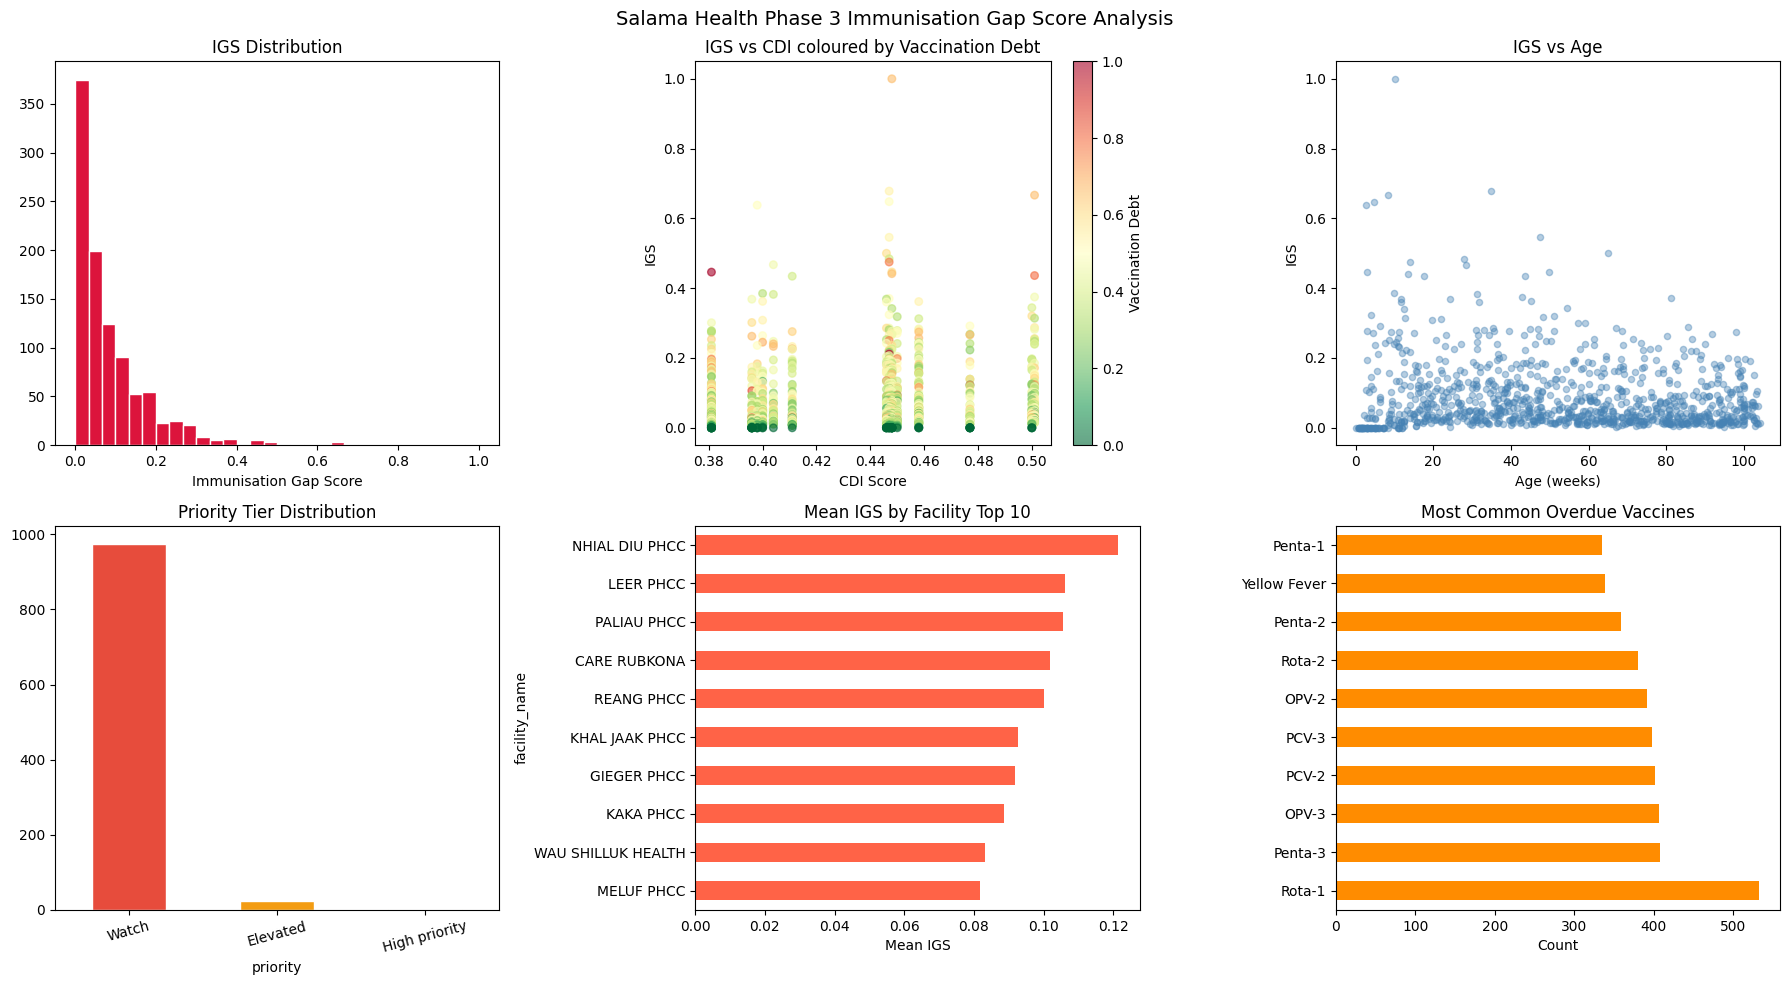

Charts saved


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# IGS distribution
axes[0, 0].hist(priority_list['IGS'], bins=30, color='crimson', edgecolor='white')
axes[0, 0].set_title('IGS Distribution')
axes[0, 0].set_xlabel('Immunisation Gap Score')

# IGS vs CDI
scatter = axes[0, 1].scatter(
    priority_list['CDI'],
    priority_list['IGS'],
    c=priority_list['vaccination_debt'],
    cmap='RdYlGn_r', alpha=0.6, s=30
)
plt.colorbar(scatter, ax=axes[0, 1], label='Vaccination Debt')
axes[0, 1].set_xlabel('CDI Score')
axes[0, 1].set_ylabel('IGS')
axes[0, 1].set_title('IGS vs CDI coloured by Vaccination Debt')

# IGS vs age
axes[0, 2].scatter(
    priority_list['age_weeks'],
    priority_list['IGS'],
    alpha=0.4, s=20, color='steelblue'
)
axes[0, 2].set_xlabel('Age (weeks)')
axes[0, 2].set_ylabel('IGS')
axes[0, 2].set_title('IGS vs Age')

# Priority distribution
priority_list['priority'].value_counts().plot(
    kind='bar', ax=axes[1, 0],
    color=['#e74c3c', '#f39c12', '#f1c40f'],
    edgecolor='white'
)
axes[1, 0].set_title('Priority Tier Distribution')
axes[1, 0].tick_params(axis='x', rotation=15)

# Mean IGS by facility top 10
fac_igs = (
    priority_list.groupby('facility_name')['IGS']
    .mean()
    .sort_values(ascending=True)
    .tail(10)
)
fac_igs.plot(kind='barh', ax=axes[1, 1], color='tomato')
axes[1, 1].set_title('Mean IGS by Facility Top 10')
axes[1, 1].set_xlabel('Mean IGS')

# Overdue vaccines frequency
all_overdue = [v for vaccines in priority_list['overdue_vaccines'] for v in vaccines]
if all_overdue:
    overdue_counts = pd.Series(all_overdue).value_counts().head(10)
    overdue_counts.plot(kind='barh', ax=axes[1, 2], color='darkorange')
    axes[1, 2].set_title('Most Common Overdue Vaccines')
    axes[1, 2].set_xlabel('Count')

plt.suptitle('Salama Health Phase 3 Immunisation Gap Score Analysis', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/igs_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Charts saved')

## 10. Facility Level Summary
What the Salama Health dashboard shows per facility.

In [12]:
facility_summary = (
    priority_list
    .groupby(['facility_name', 'state', 'county', 'CDI', 'risk_level'])
    .agg(
        total_children    = ('child_id',          'count'),
        high_priority     = ('priority',           lambda x: (x == 'High priority').sum()),
        elevated          = ('priority',           lambda x: (x == 'Elevated').sum()),
        mean_igs          = ('IGS',                'mean'),
        max_igs           = ('IGS',                'max'),
        total_overdue     = ('n_overdue',          'sum'),
        mean_vax_debt     = ('vaccination_debt',   'mean'),
        never_contacted   = ('days_since_contact', lambda x: x.isna().sum()),
    )
    .reset_index()
    .sort_values('mean_igs', ascending=False)
    .reset_index(drop=True)
)

facility_summary['mean_igs'] = facility_summary['mean_igs'].round(4)
facility_summary['max_igs']  = facility_summary['max_igs'].round(4)
facility_summary['mean_vax_debt'] = facility_summary['mean_vax_debt'].round(3)

print('Facility Dashboard Summary')
print(facility_summary.head(10).to_string(index=False))

Facility Dashboard Summary
     facility_name      state  county   CDI risk_level  total_children  high_priority  elevated  mean_igs  max_igs  total_overdue  mean_vax_debt  never_contacted
    NHIAL DIU PHCC      Unity Rubkona 0.501       High              57              1         2    0.1215   0.6666            361          0.451               16
      CARE RUBKONA      Unity Rubkona 0.448       High              54              1         1    0.1019   1.0000            315          0.430               17
        REANG PHCC      Unity Rubkona 0.446       High              47              0         3    0.1001   0.5000            242          0.402               14
    KHAL JAAK PHCC      Unity Rubkona 0.447       High              45              0         2    0.0926   0.6481            245          0.400               10
       GIEGER PHCC Upper Nile    Renk 0.450       High              45              0         0    0.0918   0.3183            235          0.404               11
 

## 11. Save All Outputs

In [13]:
# Save full priority list
priority_list.to_csv(f'{OUT_DIR}/SSD_Priority_Visit_List.csv', index=False)
print(f'Priority visit list saved: {len(priority_list):,} children')

# Save facility summary
facility_summary.to_csv(f'{OUT_DIR}/SSD_Facility_Summary.csv', index=False)
print(f'Facility summary saved: {len(facility_summary)} facilities')

# Save high priority children only
high_priority = priority_list[priority_list['priority'] == 'High priority'].copy()
high_priority.to_csv(f'{OUT_DIR}/SSD_High_Priority_Children.csv', index=False)
print(f'High priority children saved: {len(high_priority):,}')

# Summary metrics
phase3_metrics = {
    'total_children':        len(priority_list),
    'high_priority':         int((priority_list['priority'] == 'High priority').sum()),
    'elevated':              int((priority_list['priority'] == 'Elevated').sum()),
    'watch':                 int((priority_list['priority'] == 'Watch').sum()),
    'children_overdue':      int((priority_list['n_overdue'] > 0).sum()),
    'mean_igs':              round(float(priority_list['IGS'].mean()), 4),
    'mean_vaccination_debt': round(float(priority_list['vaccination_debt'].mean()), 4),
    'facilities_covered':    int(priority_list['facility_name'].nunique()),
    'season_factor':         season_factor,
    'reference_date':        str(TODAY.date()),
}
with open(f'{OUT_DIR}/phase3_metrics.json', 'w') as f:
    json.dump(phase3_metrics, f, indent=2)
print('Metrics saved')

print('\nPhase 3 Summary')
print(f'Total children:      {phase3_metrics["total_children"]:,}')
print(f'High priority:       {phase3_metrics["high_priority"]:,}')
print(f'Elevated:            {phase3_metrics["elevated"]:,}')
print(f'Children overdue:    {phase3_metrics["children_overdue"]:,}')
print(f'Mean IGS:            {phase3_metrics["mean_igs"]}')
print(f'Mean vaccination debt:{phase3_metrics["mean_vaccination_debt"]}')
print(f'Facilities covered:  {phase3_metrics["facilities_covered"]}')
print(f'\nOutputs saved to: {OUT_DIR}')

Priority visit list saved: 1,000 children
Facility summary saved: 17 facilities
High priority children saved: 3
Metrics saved

Phase 3 Summary
Total children:      1,000
High priority:       3
Elevated:            23
Children overdue:    944
Mean IGS:            0.0863
Mean vaccination debt:0.4068
Facilities covered:  19

Outputs saved to: /kaggle/working
